# Handmatig relabelen van ferPlus data

In [1]:
import pandas as pd
import numpy as np
import csv
from PIL import Image
from matplotlib import pyplot as plt
import os

Maak een map naast waar deze notebook staat met daarin de train.csv en de relabeled_data.csv. De rest gebeurt allemaal van zelf.

https://hogeschoolutrecht-my.sharepoint.com/:f:/g/personal/maria_dukmak_student_hu_nl/EmqBJYOP0vlBkooWVJumwPUBP0KgdwxJi7r9xG-n3nbjPA?e=yDvlHq \
Vanuit hier kun je de train en relabeled_data.csv downloaden, zet deze in een mapje naast dit notebook bestand.

In [2]:
existent = False

data = pd.read_csv('ferPlus_data_ready/test.csv')
if os.path.isfile("ferPlus_data_ready/test_hand_relabeled_emotions.csv"):
    existent = True
    relabeled_data = pd.read_csv('ferPlus_data_ready/test_hand_relabeled_emotions.csv')
else:
    relabeled_data = pd.read_csv('ferPlus_data_ready/test_relabeled_data.csv')
data.head(10)
relabeled_data.head()

,neutral,happiness,surprise,sadness,anger,disgust,fear,target
0,4,0,0,0,1,0,0,neutral
1,7,0,0,0,2,0,0,neutral
2,5,5,0,0,0,0,0,neutral
3,0,10,0,0,0,0,0,happiness
4,0,10,0,0,0,0,0,happiness


In [3]:
emotions = {'0':'neutral', '1':'happiness', '2':'surprise', 
            '3':'sadness', '4':'anger', '5':'disgust', '6':'fear', '7':'contempt'}

Maak een cell aan zodat de code de volgende keer weet waar je gebleven was met het labelen.

In [4]:
data['formatted_pixels'] = ''

if existent == False:
    relabeled_data['left_of'] = ''
    relabeled_data.at[0,'left_of'] = 0

Een functie voor het formatten van alle pixel string, hierna kun je de image plotten.

In [5]:
def format_pixels(data):
    for index, image_pixels in enumerate(data['pixels']):
        image_string = image_pixels.split(' ')
        image_data = np.asarray(image_string, dtype=np.uint8).reshape(48, 48)
        data.at[index,'formatted_pixels']= image_data

In [6]:
format_pixels(data)

Aanroepen van laatst gebleven positie na het stoppen van het labelen

In [7]:
begin = int(relabeled_data['left_of'].iloc[0])

Telling hoeveel rows meer dan 1 meest gekozen emotie hebben.

In [8]:
dubble_max_rows = []
tripple_max_rows = []
quadruple_max_rows = []
five_max_rows = []

multiple_max_array = []

maxes = relabeled_data.max(axis=1)

for index in range(begin, len(relabeled_data['neutral'])):
    even_emotions = []
    amount_maxes = 0
    row = relabeled_data.iloc[index]    
    
    for i, x in enumerate(row):
        if x == maxes[index]:
            even_emotions.append(emotions[str(i)])
            amount_maxes += 1
    
    if amount_maxes >= 2:
        dubble_max_rows.append(index)
        multiple_max_array.append(even_emotions)
        
    if amount_maxes >= 3:
        tripple_max_rows.append(index)
        
    if amount_maxes >= 4:
        quadruple_max_rows.append(index)
        
    if amount_maxes >= 5:
        five_max_rows.append(index)
       
print('2 the same: ', len(dubble_max_rows))
print('3 the same: ', len(tripple_max_rows))
print('4 the same: ', len(quadruple_max_rows))
print('5 the same: ', len(five_max_rows))

2 the same:  274
3 the same:  15
4 the same:  1
5 the same:  0


Het volgende zorgt er voor dat iedere image die opnieuw gelabeld moet worden vertoond wordt met de emoties waaruit gekozen zal moeten worden.


Type stop om het op te slaan, je kan het bestand daarna afsluiten. Anders kun je het numer van de emotie kiezen, de eerste in de lijst is 0, en de 2e in de lijst is 1. Deze nummers vul je in en dan zal vanzelf de goede emotie worden gekozen.

index number:  2
['neutral', 'happiness']


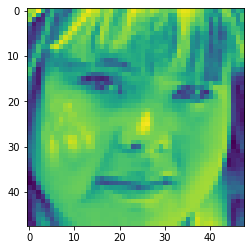

Wat is de emotie: 1


chosen before:  happiness
index number:  52
['neutral', 'sadness']


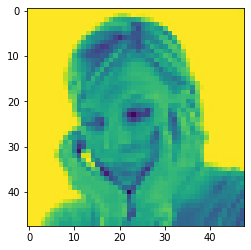

Wat is de emotie: stop


process finished


In [9]:
for index, row_index in enumerate(dubble_max_rows):
    row = data.iloc[row_index]
    
    image = row['formatted_pixels']
    img = Image.fromarray(image)
    imgplot = plt.imshow(img)
    
    print('index number: ', row_index)
    print(multiple_max_array[index])
    plt.show()
    
    chosen_emotion = ''
    
    while chosen_emotion not in emotions and chosen_emotion != 'stop':   
        chosen_emotion = input('Wat is de emotie: ')
    print('\n')
    
    if chosen_emotion == 'stop': 
        relabeled_data.at[0,'left_of'] = row_index
        break
    else:
        relabeled_data.at[row_index,'target'] = multiple_max_array[index][int(chosen_emotion)]
        print('chosen before: ', multiple_max_array[index][int(chosen_emotion)])
        
relabeled_data.to_csv("ferPlus_data_ready/test_hand_relabeled_emotions.csv", index=False)
print('process finished')

Als je klaar bent kun je hand_relabeled_emotions doorsturen naar mij.